# Phase 5 guide — post-quantum-secured federated communication

This read-only guide explains the implemented security layer using saved, secret-free evidence. The Docker implementation remains in `phase5/app/`; this notebook does not provision identities, load private keys, perform training, or duplicate the cryptographic protocol.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

HERE = Path.cwd().resolve()
PROJECT_ROOT = HERE if (HERE / "phase5" / "results" / "benchmark_comparison.json").is_file() else HERE.parent
if not (PROJECT_ROOT / "phase5" / "results" / "benchmark_comparison.json").is_file():
    raise RuntimeError("Run from the uavids_federated root or notebooks directory")

RESULTS = PROJECT_ROOT / "phase5" / "results"
CONFIG = json.loads((PROJECT_ROOT / "phase5" / "config" / "security_config.json").read_text(encoding="utf-8"))
BENCHMARK = json.loads((RESULTS / "benchmark_comparison.json").read_text(encoding="utf-8"))
print("Loaded stable Phase 5 evidence; no runtime key directory was accessed.")
print(BENCHMARK["algorithms"])

Loaded stable Phase 5 evidence; no runtime key directory was accessed.
{'aead': 'AES-256-GCM', 'kdf': 'HKDF-SHA-256', 'kem': 'ML-KEM-768', 'signature': 'ML-DSA-65'}


## Threat and trust model

The network attacker can observe, alter, inject, copy, delay, and replay HTTP application messages or claim another client name. The host, Docker engine, pinned libraries, training implementation, mounted secrets, and provisioned public trust store are trusted. Host compromise, denial of service, traffic analysis, key theft, and malicious updates from an already authenticated client are outside scope.

## What each primitive contributes

| Primitive | Contribution |
|---|---|
| ML-KEM-768 | Establishes shared cryptographic material without sending it |
| HKDF-SHA-256 | Derives independent directional AES keys and nonce prefixes |
| AES-256-GCM | Encrypts and authenticates model requests, models, events, updates, and acknowledgements |
| ML-DSA-65 | Authenticates provisioned server/client identities and binds the handshake |

Both selected post-quantum parameter sets are NIST security category 3. Final standardized ML-KEM/ML-DSA names are used, not legacy Kyber/Dilithium names.

## One protected exchange

```text
client                              control center
  |-- identity + registration -------->|
  |<-- signed ephemeral ML-KEM key -----|
  |-- signed KEM ciphertext ----------->|
  |<-- AES-GCM confirmation ------------|
  |-- encrypted model request ---------->|
  |<-- encrypted global model ----------|
  |   local training                    |
  |-- encrypted client update --------->|
  |   verify before model decoding      |
  |                         safe FedAvg  |
```

The signed handshake binds the client, run, frozen contract, algorithms, challenges, and KEM key/ciphertext hashes. Each AES-GCM header binds protocol version, session, run, round, sender, recipient, message type, sequence, nonce, contract hash, plaintext hash, and model hash as canonical authenticated data.

In [2]:
safe_header_example = {
    "security_version": CONFIG["security_version"],
    "session_id": "example-session",
    "run_id": "example-run",
    "round": 2,
    "sender": "uav-client-1",
    "recipient": "control-center",
    "message_type": "client_update",
    "sequence": 7,
    "nonce": "<derived-prefix || uint64-sequence>",
    "contract_hash": "<frozen-contract-hash>",
    "plaintext_sha256": "<update-plaintext-hash>",
    "model_sha256": "<model-hash>",
}
display(pd.DataFrame(safe_header_example.items(), columns=["bound field", "illustrative value"]))

,bound field,illustrative value
0,security_version,uavids-phase5-security-v1
1,session_id,example-session
2,run_id,example-run
3,round,2
4,sender,uav-client-1
5,recipient,control-center
6,message_type,client_update
7,sequence,7
8,nonce,<derived-prefix || uint64-sequence>
9,contract_hash,<frozen-contract-hash>


## Replay, tampering, and impersonation

Each direction uses a different key. A 96-bit nonce combines a direction-specific four-byte HKDF output with an eight-byte sequence. The receiver requires the next sequence and exact nonce; AES-GCM authentication must pass before plaintext JSON or model archives are decoded. The public trust store maps one approved ML-DSA identity to each logical client, so a signature or key cannot silently migrate to another name.

In [3]:
rejections = pd.read_csv(RESULTS / "rejection_summary.csv")
assert set(rejections["category"]) == {
    "authentication_failed", "malformed_payload", "metadata_mismatch",
    "nonce_invalid", "replay", "signature_invalid", "untrusted_identity"
}
display(rejections)
print(f"Controlled attack run completed with {int(rejections['count'].sum())} rejected messages; valid training still completed.")
assert BENCHMARK["attack_test"]["all_aggregate_archives_identical_to_plain"]
print("All attack-run aggregate archives were byte-identical to plain mode.")

,category,count
0,authentication_failed,2
1,malformed_payload,1
2,metadata_mismatch,5
3,nonce_invalid,1
4,replay,1
5,signature_invalid,1
6,untrusted_identity,1


Controlled attack run completed with 12 rejected messages; valid training still completed.
All attack-run aggregate archives were byte-identical to plain mode.


## Plain versus secure equivalence

The comparison is meaningful because the security adapter calls the unchanged Phase 4 coordinator. It demonstrates that protecting transport did not alter client sample counts, local updates, or FedAvg. It does not demonstrate robustness against poisoned—but correctly authenticated—updates.

In [4]:
aggregation = pd.DataFrame([{
    "plain run": BENCHMARK["plain_run_id"],
    "secure run": BENCHMARK["secure_run_id"],
    "clients": BENCHMARK["clients"],
    "rounds": BENCHMARK["rounds"],
    "samples/round": BENCHMARK["samples_per_round"],
    "plain-secure max abs diff": BENCHMARK["aggregation"]["maximum_plain_secure_difference"],
    "independent secure max abs diff": BENCHMARK["aggregation"]["maximum_independent_secure_difference"],
    "tolerance": BENCHMARK["aggregation"]["tolerance"],
}])
display(aggregation)
assert BENCHMARK["aggregation"]["maximum_plain_secure_difference"] <= BENCHMARK["aggregation"]["tolerance"]

,plain run,secure run,clients,rounds,samples/round,plain-secure max abs diff,independent secure max abs diff,tolerance
0,00647f41-ff4f-49e1-8101-1867e3683453,23795a6c-4d27-4d27-96e1-1da6954d7c9c,5,3,6148,0.0,0.0,1.000000e-07


## Measured cryptographic and message overhead

Operation timings isolate the primitives from training and container startup. These are small repeated measurements within one final run, not hardware-independent benchmarks. Full runtimes vary with container startup and concurrent CPU scheduling.

,operation,count,mean,median,min,max
0,decapsulation_ms,5,0.1444,0.1375,0.0741,0.2533
1,decrypt_ms,142,0.0973,0.0595,0.0370,1.2739
2,encapsulation_ms,5,2.3707,1.7476,1.4767,4.9473
3,encrypt_ms,202,0.0655,0.0580,0.0115,0.2664
4,server_signature_verification_ms,5,0.4799,0.2976,0.2690,1.0437
5,sign_ms,5,1.2936,0.5329,0.3862,4.3238
6,signing_ms,5,0.4947,0.3502,0.2363,0.9220
7,verify_ms,5,0.6281,0.4687,0.3721,1.1604


,direction,messages,mean_plaintext_bytes,mean_protected_bytes,mean_overhead_bytes,mean_expansion_percent
0,server_to_client,15,65596.00,88043.80,22447.8,34.22
1,client_to_server,15,64279.27,86289.47,22010.2,34.24


,client_id,samples,mean_training_ms,max_training_ms,encapsulation_ms,signing_ms,mean_encrypt_ms,mean_decrypt_ms,sent_messages,received_messages,peak_cpu_percent,peak_memory_mib
0,uav-client-1,1230,768.321,2168.595,1.657,0.686,0.067,0.083,49,37,69.13,274.2
1,uav-client-2,1046,957.645,2704.245,2.025,0.350,0.069,0.105,45,33,61.52,272.6
2,uav-client-3,591,1625.086,4693.740,4.947,0.922,0.073,0.288,16,4,36.80,272.5
3,uav-client-4,2027,724.646,1923.522,1.748,0.236,0.057,0.089,60,48,101.46,274.2
4,uav-client-5,1254,1199.657,3411.007,1.477,0.279,0.069,0.091,32,20,47.52,274.1


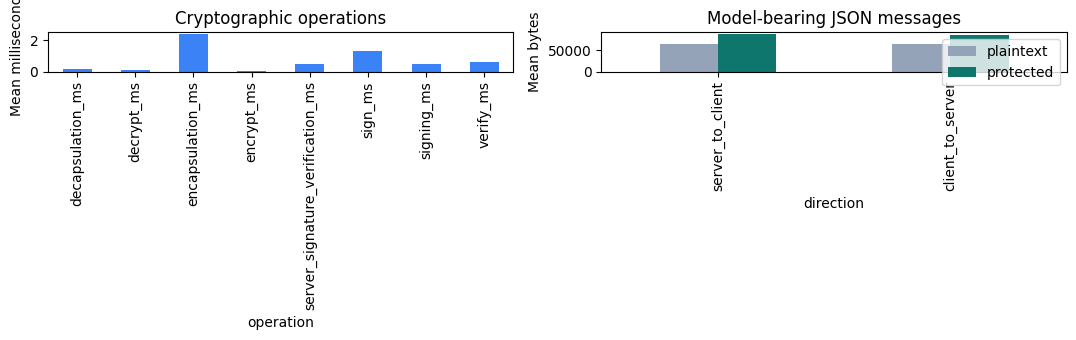

In [5]:
timings = pd.read_csv(RESULTS / "crypto_operation_timings.csv")
sizes = pd.read_csv(RESULTS / "message_size_comparison.csv")
clients = pd.read_csv(RESULTS / "per_client_secure_metrics.csv")
display(timings.round(4))
display(sizes.round(2))
display(clients.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
timings.plot.bar(x="operation", y="mean", legend=False, ax=axes[0], color="#3b82f6")
axes[0].set_ylabel("Mean milliseconds")
axes[0].set_title("Cryptographic operations")
sizes.plot.bar(x="direction", y=["mean_plaintext_bytes", "mean_protected_bytes"], ax=axes[1], color=["#94a3b8", "#0f766e"])
axes[1].set_ylabel("Mean bytes")
axes[1].set_title("Model-bearing JSON messages")
axes[1].legend(["plaintext", "protected"])
plt.tight_layout()
plt.show()

Client 3 remained the first-round training straggler despite having the smallest partition, consistent with its tighter CPU profile and one-time startup effects. AES-GCM times stayed sub-millisecond for every client; single-handshake ML-KEM/ML-DSA differences are descriptive noise, not evidence of device-specific cryptographic performance.

In [6]:
runtime = BENCHMARK["runtime_seconds"]
display(pd.DataFrame({
    "mode": ["plain", "secure"],
    "coordinator seconds": [runtime["plain_coordinator"], runtime["secure_coordinator"]],
    "compose-to-terminal seconds": [runtime["plain_compose_to_terminal"], runtime["secure_compose_to_terminal"]],
}))
print("Completed normal secure coordinator repetitions:", runtime["secure_completed_repetitions"])
print(BENCHMARK["scope"])

,mode,coordinator seconds,compose-to-terminal seconds
0,plain,32.349819,44.936032
1,secure,27.582403,36.901957


Completed normal secure coordinator repetitions: [24.695957, 27.582403]
demonstration timing only; not a rigorous performance conclusion


## Run and verify

```powershell
# unchanged plain baseline
powershell.exe -NoProfile -ExecutionPolicy Bypass -File .\phase4\scripts\run_demo.ps1

# secure demo and controlled attacks
powershell.exe -NoProfile -ExecutionPolicy Bypass -File .\phase5\scripts\run_secure_demo.ps1
powershell.exe -NoProfile -ExecutionPolicy Bypass -File .\phase5\scripts\run_attack_tests.ps1

# regressions and observation
powershell.exe -NoProfile -ExecutionPolicy Bypass -File .\phase5\scripts\run_security_tests.ps1
powershell.exe -NoProfile -ExecutionPolicy Bypass -File .\phase5\scripts\observe_secure_demo.ps1
powershell.exe -NoProfile -ExecutionPolicy Bypass -File .\phase5\scripts\stop_secure_demo.ps1
```

## Valid claims and limitations

This controlled prototype demonstrates confidential, authenticated, tamper-evident, context-bound, replay-resistant model exchange and aggregation-equivalent FL. Provisioning is an academic allowlist, not production PKI; HTTP metadata is visible; keys lack certificate/revocation/HSM lifecycle; the server sees plaintext updates; and encryption does not detect model poisoning. It implements neither secure aggregation nor differential privacy and must not be described as production-ready.

A later packet-capture comparison should show readable model-bearing JSON in plain mode and only headers plus ciphertext/base64 in secure mode, while carefully stating that IP/HTTP sizes and timing remain observable.